In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammainc, gamma
from scipy.optimize import root
import matplotlib.colors as mcolors

# Physical constants

G = 6.67e-11
c = 3e8

# Sérsic parameters
n = 4
b = 1.9992*n - 0.3271
r_e = 3.086e21

# Lens distance
D_d = 1.0e25

# Source distance
D_s = 2.0e25
D_ds = D_s - D_d

# Galaxy catalogue

RA = np.array([
180.1711571,180.1706384,180.1670402,180.1669367,180.1649901,
180.1647511,180.1620085,180.1585672,180.1578159,180.1571312,
180.1547416
])

DEC = np.array([
-1.448282774,-1.45269478,-1.452993158,-1.451199272,-1.449266441,
-1.460621377,-1.446011697,-1.447444124,-1.451612291,-1.452994629,
-1.446817617
])

RA = np.deg2rad(RA)
DEC = np.deg2rad(DEC)

# Find the most central galaxy

mean_RA = np.mean(RA)
mean_DEC = np.mean(DEC)

dist = np.sqrt((RA-mean_RA)**2 + (DEC-mean_DEC)**2)

central_index = np.argmin(dist)

RA0 = RA[central_index]
DEC0 = DEC[central_index]

# Convert RA/Dec to angular offsets

theta_x = (RA - RA0)*np.cos(DEC0)
theta_y = (DEC - DEC0)

galaxy_positions = np.vstack([theta_x, theta_y]).T

# Lens masses

N_gal = len(galaxy_positions)

M = np.ones(N_gal)*2e40

Sigma_crit = (c**2/(4*np.pi*G))*(D_s/(D_d*D_ds))
Sigma_e = M/(2*np.pi*r_e**2)

kappa_e = Sigma_e/Sigma_crit

alpha_e = n*r_e*kappa_e*(b**(-2*n))*np.exp(b)*gamma(2*n)

# Einstein radius scale

theta_E = np.sqrt((4*G*np.mean(M))/(c**2)*D_ds/(D_d*D_s))

# Rescale galaxy positions

cluster_radius = np.max(np.linalg.norm(galaxy_positions,axis=1))

target_radius = 3*theta_E

scale_factor = target_radius/cluster_radius

galaxy_positions *= scale_factor

# Source positions (inside cluster)

β_1 = np.array([1.0*theta_E, 0.5*theta_E])
β_2 = np.array([2*theta_E, -1.5*theta_E])

In [57]:

# Sérsic deflection

def sersic_deflection(theta,O,alpha_e):

    r_vec = theta - O
    r_ang = np.linalg.norm(r_vec)

    if r_ang == 0:
        return np.array([0.0,0.0])

    r = D_d*r_ang

    x = (r/r_e)**(1/n)
    x = max(x,1e-12)

    alpha_mag = 2*alpha_e*x**(-n)*(1-gammainc(2*n,b*x))

    alpha_vec = alpha_mag*r_vec/r_ang

    return alpha_vec/D_d

# Total deflection

def total_deflection(theta):

    total = np.array([0.0,0.0])

    for i in range(N_gal):

        total += sersic_deflection(theta,
                                   galaxy_positions[i],
                                   alpha_e[i])

    return total


def lens_equation(theta,beta):

    theta = np.array(theta)

    return theta - total_deflection(theta) - beta

# Image finder

def find_images(beta, n_guesses=2000, perturb=5*theta_E, duplicate_tol=0.000004):
    beta = np.array(beta)
    solutions = []
    guesses = beta + np.random.uniform(-perturb, perturb, size=(n_guesses, 2))
    for g in guesses:
        sol = root(lens_equation, g, args=(beta,))
        if sol.success:
            θ = sol.x
            if np.linalg.norm(lens_equation(θ,beta)) > 1e-7:
                continue
            if not any(np.linalg.norm(θ - s) < duplicate_tol for s in solutions):
                solutions.append(θ)
    solutions.sort(key=lambda θ: np.linalg.norm(θ - beta))
    return solutions


images_1 = find_images(β_1)
images_2 = find_images(β_2)

print("Images source 1:",len(images_1))
print("Images source 2:",len(images_2))

# Magnification

def magnification(theta,beta):

    eps = 1e-8

    dtheta_x = np.array([eps,0])
    dtheta_y = np.array([0,eps])

    beta_x1 = lens_equation(theta+dtheta_x,beta)
    beta_x2 = lens_equation(theta-dtheta_x,beta)

    beta_y1 = lens_equation(theta+dtheta_y,beta)
    beta_y2 = lens_equation(theta-dtheta_y,beta)

    dβ_dx = (beta_x1-beta_x2)/(2*eps)
    dβ_dy = (beta_y1-beta_y2)/(2*eps)

    J = np.array([[dβ_dx[0],dβ_dy[0]],
                  [dβ_dx[1],dβ_dy[1]]])

    detJ = np.linalg.det(J)

    return 1/abs(detJ)


mu_1=[magnification(θ,β_1) for θ in images_1]
mu_2=[magnification(θ,β_2) for θ in images_2]


Images source 1: 5
Images source 2: 5


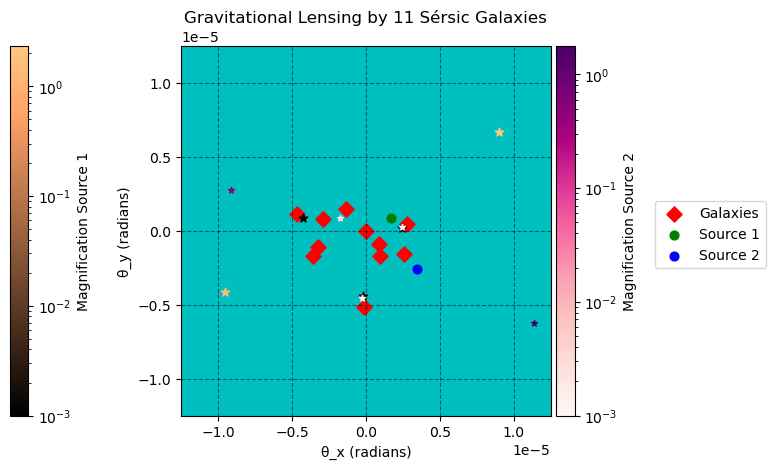

In [58]:

# Plot

fig,ax = plt.subplots()

ax.set_aspect('equal')

# galaxies
ax.scatter(galaxy_positions[:,0],
           galaxy_positions[:,1],
           color='red',
           marker='D',
           s=60,
           label="Galaxies")

# sources
ax.scatter(β_1[0],β_1[1],color='green',s=40,label="Source 1")
ax.scatter(β_2[0],β_2[1],color='blue',s=40,label="Source 2")

# colormaps
cmap1 = plt.cm.copper
cmap2 = plt.cm.RdPu

norm1 = mcolors.LogNorm(vmin=max(min(mu_1),1e-3),vmax=max(mu_1))
norm2 = mcolors.LogNorm(vmin=max(min(mu_2),1e-3),vmax=max(mu_2))

sm1 = plt.cm.ScalarMappable(norm=norm1, cmap=cmap1)
cbar1 = plt.colorbar(sm1, ax=ax, fraction=0.046, pad=-1.2)
cbar1.set_label("Magnification Source 1")

sm2 = plt.cm.ScalarMappable(norm=norm2, cmap=cmap2)
cbar2 = plt.colorbar(sm2, ax=ax, fraction=0.046, pad=0.005)
cbar2.set_label("Magnification Source 2")

for i,θ in enumerate(images_1):

    ax.scatter(θ[0],θ[1],
               marker='*',
               s=40,
               color=cmap1(norm1(mu_1[i])),
               )

for i,θ in enumerate(images_2):

    ax.scatter(θ[0],θ[1],
               marker='*',
               s=20,
               color=cmap2(norm2(mu_2[i])),
               )

# limits
all_positions = np.vstack([images_1, images_2, galaxy_positions, [β_1, β_2]])
max_range = np.max(np.abs(all_positions)) * 1.1

ax.set_facecolor('c')

ax.set_xlim(-max_range,max_range)
ax.set_ylim(-max_range,max_range)

ax.grid(True,linestyle='--',alpha=0.5, color='black')

ax.set_xlabel("θ_x (radians)")
ax.set_ylabel("θ_y (radians)")

ax.set_title("Gravitational Lensing by 11 Sérsic Galaxies")

ax.legend(loc='upper right', bbox_to_anchor=(1.6, 0.6))

plt.show()
